<a href="https://colab.research.google.com/github/nikini-wanigasekara/-Statistical-Learning-e23418/blob/main/GPR_LR_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPR & Linear Regression Assignment

Energy Efficiency Analysis using Gaussian Process Regression and Linear Regression

## 0. Imports & Setup

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.feature_selection import f_regression
from scipy import stats

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("All packages loaded successfully.")


All packages loaded successfully.


---
# Part 1: Gaussian Process Regression

**Dataset:** ENB2012 Energy Efficiency Dataset  
8 building-physics features (X1–X8), two targets: **Y1 (Heating Load)** and **Y2 (Cooling Load)**

> The question asks us to explore modeling *both* Y1 and Y2 as a **single-parameter** Gaussian process — i.e., can a GPR trained on one combined/single output adequately capture both loads?


### 1.1 Load & Explore Data

In [ ]:

# ── If running on Colab with kagglehub, replace this block with the kagglehub download ──
# import kagglehub
# path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")
# df = pd.read_csv(path + "/ENB2012_data.csv")

# ── Offline / local run ──
df = pd.read_csv("ENB2012_data.csv")

feature_names = {
    'X1': 'Relative Compactness',
    'X2': 'Surface Area (m²)',
    'X3': 'Wall Area (m²)',
    'X4': 'Roof Area (m²)',
    'X5': 'Overall Height (m)',
    'X6': 'Orientation',
    'X7': 'Glazing Area',
    'X8': 'Glazing Area Distribution'
}
print(f"Shape: {df.shape}")
df.head()


Shape: (768, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,22.97,21.04
1,0.98,514.5,294.0,110.25,7.0,2,0.1,1,23.71,25.28
2,0.98,514.5,294.0,110.25,7.0,2,0.1,2,24.66,24.17
3,0.98,514.5,294.0,110.25,7.0,2,0.1,3,25.71,22.90
4,0.98,514.5,294.0,110.25,7.0,2,0.1,4,23.60,24.10


In [ ]:

print("\nDescriptive Statistics:")
df.describe().round(3)



Descriptive Statistics:


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,0.764,671.708,324.625,178.646,5.250,3.500,0.234,2.812,23.564,24.319
std,0.106,88.086,48.130,38.262,1.751,1.119,0.133,1.551,8.455,6.101
min,0.620,514.500,245.000,110.250,3.500,2.000,0.000,0.000,6.000,10.900
25%,0.682,606.375,294.000,147.000,3.500,2.750,0.100,1.750,15.788,19.228
50%,0.750,673.750,318.500,183.750,5.250,3.500,0.250,3.000,23.940,24.605
75%,0.830,741.125,349.125,220.500,7.000,4.250,0.400,4.000,31.428,29.482
max,0.980,808.500,416.500,220.500,7.000,5.000,0.400,5.000,40.310,37.070


Missing values: 0


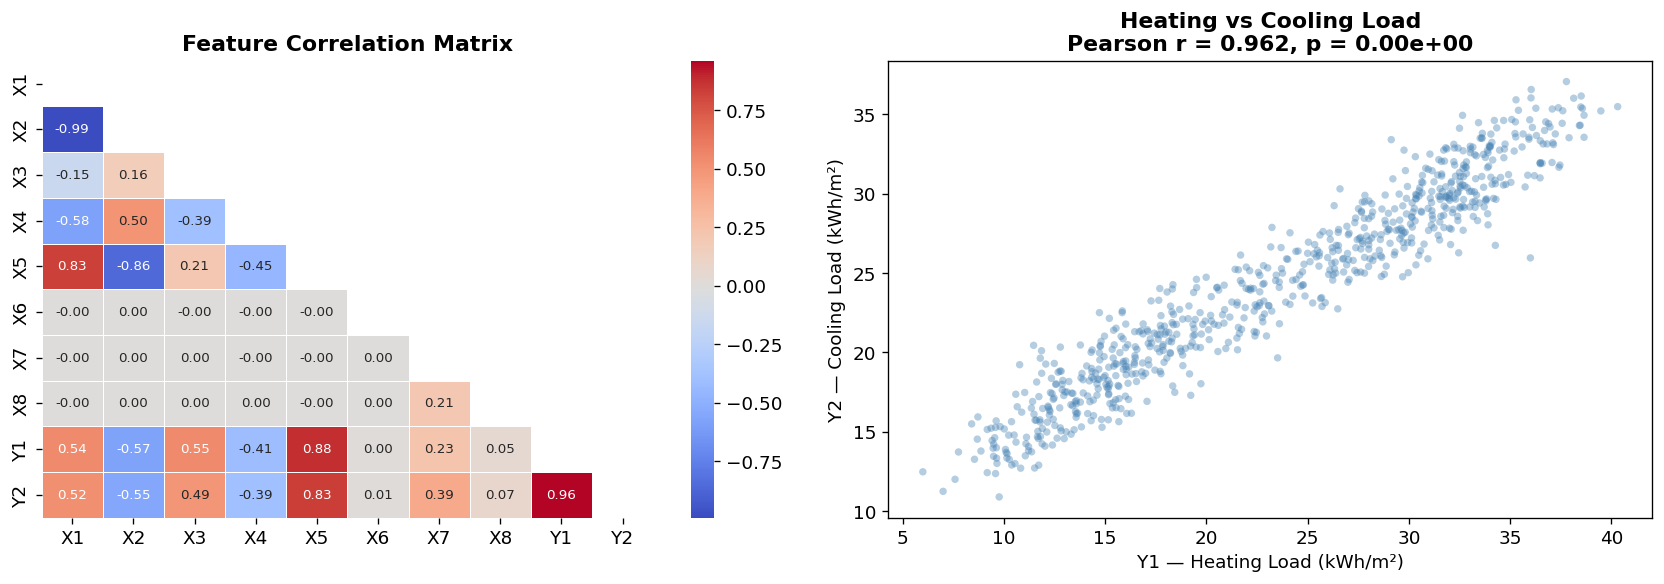

Correlation between Y1 and Y2: r = 0.9619


In [ ]:

print("Missing values:", df.isnull().sum().sum())

# Correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title("Feature Correlation Matrix", fontweight='bold')

# Y1 vs Y2
axes[1].scatter(df['Y1'], df['Y2'], alpha=0.4, s=20, color='steelblue', edgecolors='none')
r, p = stats.pearsonr(df['Y1'], df['Y2'])
axes[1].set_xlabel("Y1 — Heating Load (kWh/m²)", fontsize=11)
axes[1].set_ylabel("Y2 — Cooling Load (kWh/m²)", fontsize=11)
axes[1].set_title(f"Heating vs Cooling Load\nPearson r = {r:.3f}, p = {p:.2e}", fontweight='bold')

plt.tight_layout()
plt.savefig('gpr_eda.png', bbox_inches='tight')
plt.show()
print(f"Correlation between Y1 and Y2: r = {r:.4f}")


### 1.2 Single-Parameter GPR: Concept

The assignment asks us to investigate a **single-parameter GP** for *both* Y1 and Y2.

Three interpretations are explored:

| Approach | Description |
|---|---|
| **A** | Combined target: `Y_combined = (Y1 + Y2) / 2` — average load |
| **B** | Sequential: train one GPR on Y1, one on Y2, compare structure |
| **C** | Single GPR output per target, evaluate whether one GP can substitute both |


In [ ]:

# ── Preprocessing ──
X = df[['X1','X2','X3','X4','X5','X6','X7','X8']].values
Y1 = df['Y1'].values
Y2 = df['Y2'].values
Y_combined = (Y1 + Y2) / 2.0   # single-parameter combined target

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# 70/30 split — use a subset for GPR (GPR scales as O(n³))
X_tr, X_te, y1_tr, y1_te, y2_tr, y2_te, yc_tr, yc_te = train_test_split(
    X_scaled, Y1, Y2, Y_combined, test_size=0.3, random_state=42
)

# GPR is expensive: subsample training set
N_TRAIN = 200
idx = np.random.default_rng(42).choice(len(X_tr), N_TRAIN, replace=False)
X_tr_s, y1_tr_s, y2_tr_s, yc_tr_s = X_tr[idx], y1_tr[idx], y2_tr[idx], yc_tr[idx]

print(f"Training subset: {X_tr_s.shape[0]} | Test set: {X_te.shape[0]}")


Training subset: 200 | Test set: 231


In [ ]:

# ── Kernel Definition ──
# Matérn-5/2 is preferred for physical systems (finite differentiability)
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(8), nu=2.5) + WhiteKernel(noise_level=1e-2)

# ── Approach A: Single-parameter GPR on combined target ──
gpr_combined = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                         normalize_y=True, random_state=42)
gpr_combined.fit(X_tr_s, yc_tr_s)
yc_pred, yc_std = gpr_combined.predict(X_te, return_std=True)

print("=== Approach A: GPR on Combined Target (Y1+Y2)/2 ===")
rmse_c = np.sqrt(mean_squared_error(yc_te, yc_pred))
r2_c   = r2_score(yc_te, yc_pred)
print(f"  RMSE : {rmse_c:.3f} kWh/m²")
print(f"  R²   : {r2_c:.4f}")
print(f"  Optimized kernel: {gpr_combined.kernel_}")


=== Approach A: GPR on Combined Target (Y1+Y2)/2 ===
  RMSE : 0.771 kWh/m²
  R²   : 0.9880
  Optimized kernel: 5.09**2 * Matern(length_scale=[25.8, 1e+05, 30.6, 1e+05, 0.14, 1e+05, 32, 9.93e+04], nu=2.5) + WhiteKernel(noise_level=0.0119)


In [ ]:

# ── Approach B: Separate GPRs for Y1 and Y2 ──
kernel2 = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(8), nu=2.5) + WhiteKernel(noise_level=1e-2)
kernel3 = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(8), nu=2.5) + WhiteKernel(noise_level=1e-2)

gpr_y1 = GaussianProcessRegressor(kernel=kernel2, n_restarts_optimizer=5,
                                    normalize_y=True, random_state=42)
gpr_y1.fit(X_tr_s, y1_tr_s)
y1_pred, y1_std = gpr_y1.predict(X_te, return_std=True)

gpr_y2 = GaussianProcessRegressor(kernel=kernel3, n_restarts_optimizer=5,
                                    normalize_y=True, random_state=42)
gpr_y2.fit(X_tr_s, y2_tr_s)
y2_pred, y2_std = gpr_y2.predict(X_te, return_std=True)

print("=== Approach B: Separate GPRs ===")
for name, y_te, y_pr in [("Y1 Heating", y1_te, y1_pred), ("Y2 Cooling", y2_te, y2_pred)]:
    rmse = np.sqrt(mean_squared_error(y_te, y_pr))
    r2   = r2_score(y_te, y_pr)
    print(f"  {name}: RMSE={rmse:.3f}, R²={r2:.4f}")


=== Approach B: Separate GPRs ===
  Y1 Heating: RMSE=1.224, R²=0.9781
  Y2 Cooling: RMSE=1.005, R²=0.9715


In [ ]:

# ── Approach C: Can single GPR (combined) predict individual loads? ──
# Use the combined-trained GPR to back-predict Y1 and Y2 individually
# This tests whether a single-parameter model is sufficient
print("=== Approach C: Can combined GPR substitute individual models? ===")
print()
print("Combined GPR predictions vs Y1 and Y2 individually:")
r2_c_y1 = r2_score(y1_te, yc_pred)
r2_c_y2 = r2_score(y2_te, yc_pred)
print(f"  Combined GPR vs Y1: R² = {r2_c_y1:.4f}")
print(f"  Combined GPR vs Y2: R² = {r2_c_y2:.4f}")
print()
print(f"  Dedicated Y1 GPR:   R² = {r2_score(y1_te, y1_pred):.4f}")
print(f"  Dedicated Y2 GPR:   R² = {r2_score(y2_te, y2_pred):.4f}")


=== Approach C: Can combined GPR substitute individual models? ===

Combined GPR predictions vs Y1 and Y2 individually:
  Combined GPR vs Y1: R² = 0.9538
  Combined GPR vs Y2: R² = 0.9197

  Dedicated Y1 GPR:   R² = 0.9781
  Dedicated Y2 GPR:   R² = 0.9715


### 1.3 Results Visualisation

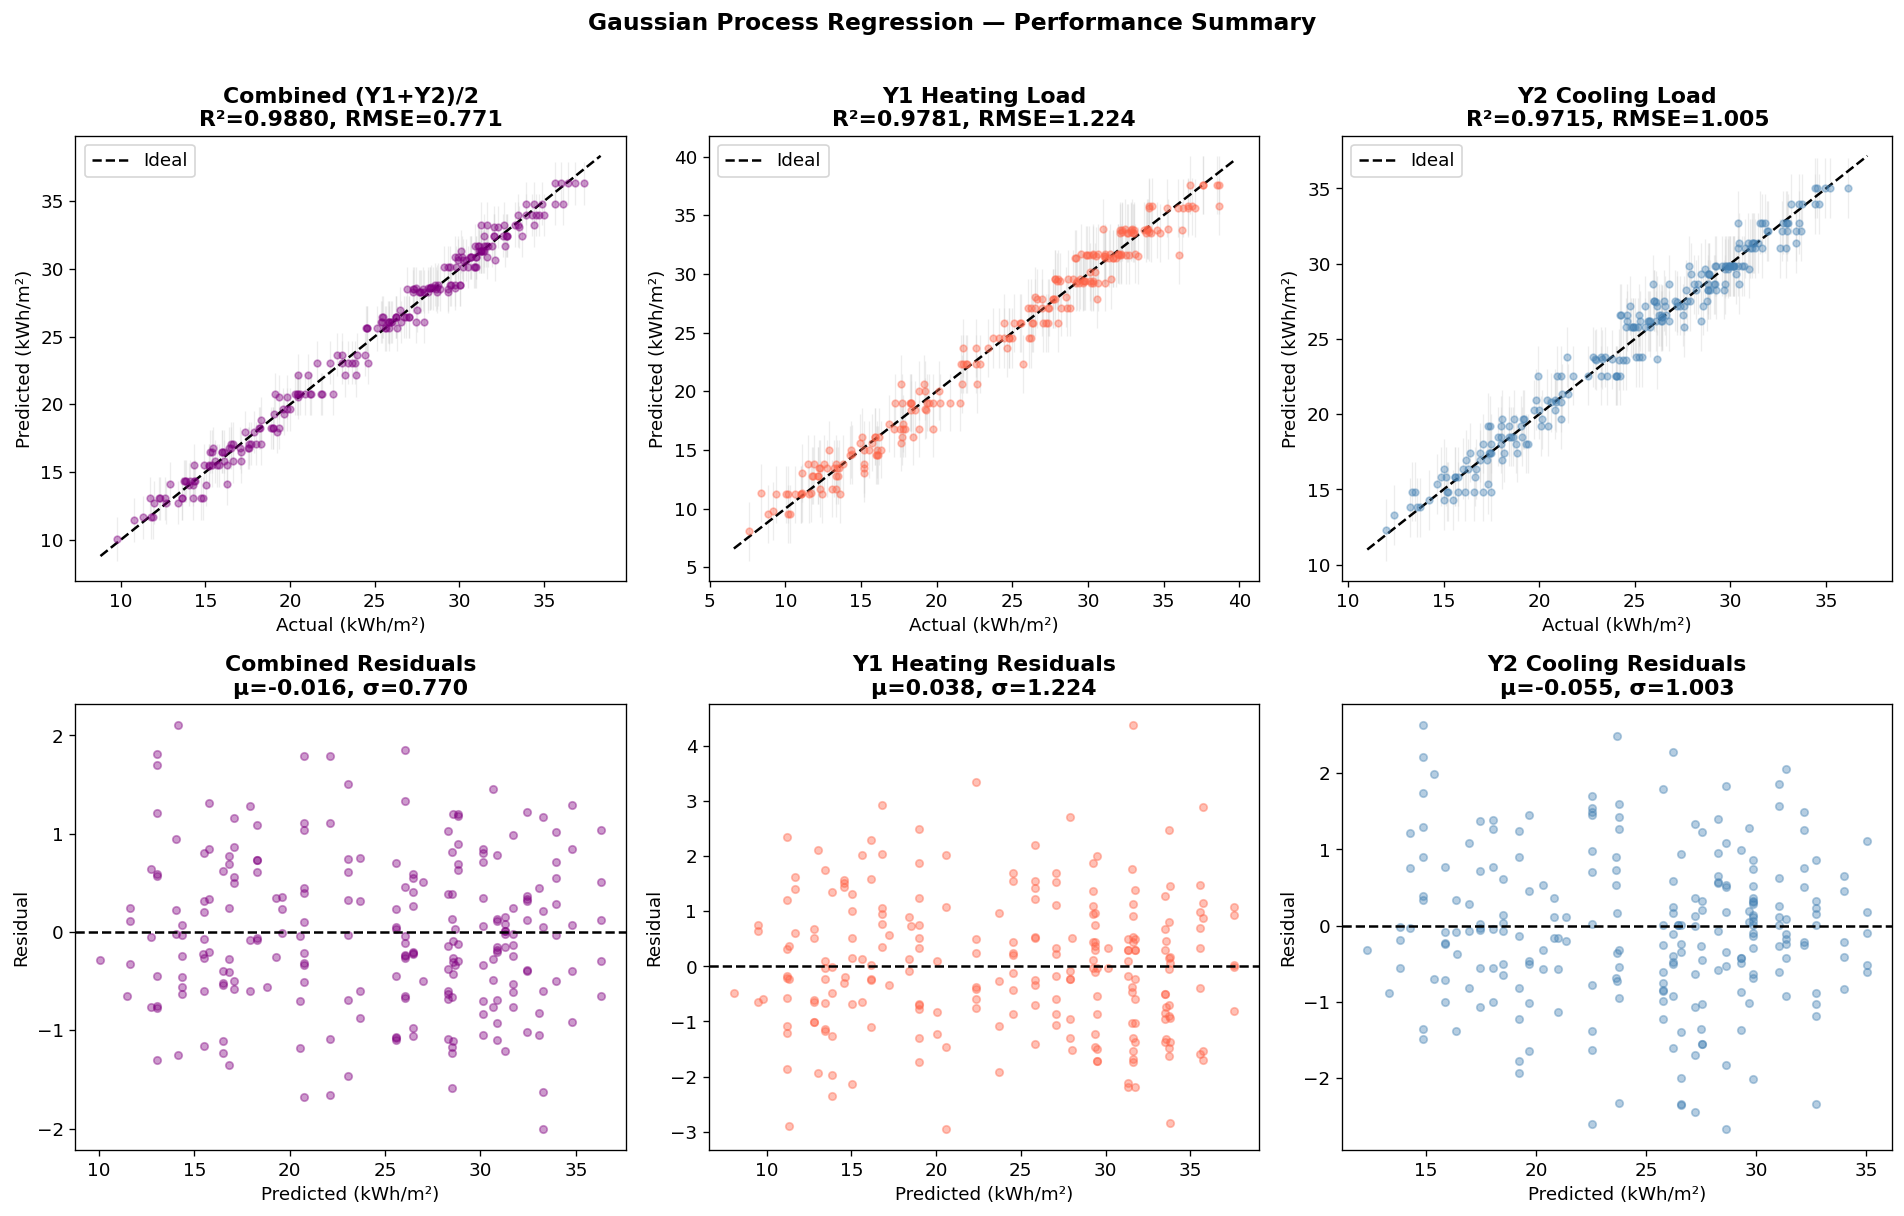

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 0: Parity plots
for ax, y_te, y_pr, y_std_v, title, color in zip(
    axes[0],
    [yc_te, y1_te, y2_te],
    [yc_pred, y1_pred, y2_pred],
    [yc_std, y1_std, y2_std],
    ['Combined (Y1+Y2)/2', 'Y1 Heating Load', 'Y2 Cooling Load'],
    ['purple', 'tomato', 'steelblue']
):
    ax.errorbar(y_te, y_pr, yerr=1.96*y_std_v, fmt='o', alpha=0.4, color=color,
                ecolor='lightgray', elinewidth=0.8, capsize=0, markersize=4)
    lims = [min(y_te.min(), y_pr.min())-1, max(y_te.max(), y_pr.max())+1]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Ideal')
    ax.set_xlabel("Actual (kWh/m²)"); ax.set_ylabel("Predicted (kWh/m²)")
    r2 = r2_score(y_te, y_pr)
    rmse = np.sqrt(mean_squared_error(y_te, y_pr))
    ax.set_title(f"{title}\nR²={r2:.4f}, RMSE={rmse:.3f}", fontweight='bold')
    ax.legend()

# Row 1: Uncertainty distributions + residuals
for ax, y_te, y_pr, y_std_v, title, color in zip(
    axes[1],
    [yc_te, y1_te, y2_te],
    [yc_pred, y1_pred, y2_pred],
    [yc_std, y1_std, y2_std],
    ['Combined', 'Y1 Heating', 'Y2 Cooling'],
    ['purple', 'tomato', 'steelblue']
):
    residuals = y_te - y_pr
    ax.scatter(y_pr, residuals, alpha=0.4, s=20, color=color)
    ax.axhline(0, color='black', linestyle='--', lw=1.5)
    ax.set_xlabel("Predicted (kWh/m²)"); ax.set_ylabel("Residual")
    ax.set_title(f"{title} Residuals\nμ={residuals.mean():.3f}, σ={residuals.std():.3f}", fontweight='bold')

plt.suptitle("Gaussian Process Regression — Performance Summary", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gpr_results.png', bbox_inches='tight')
plt.show()


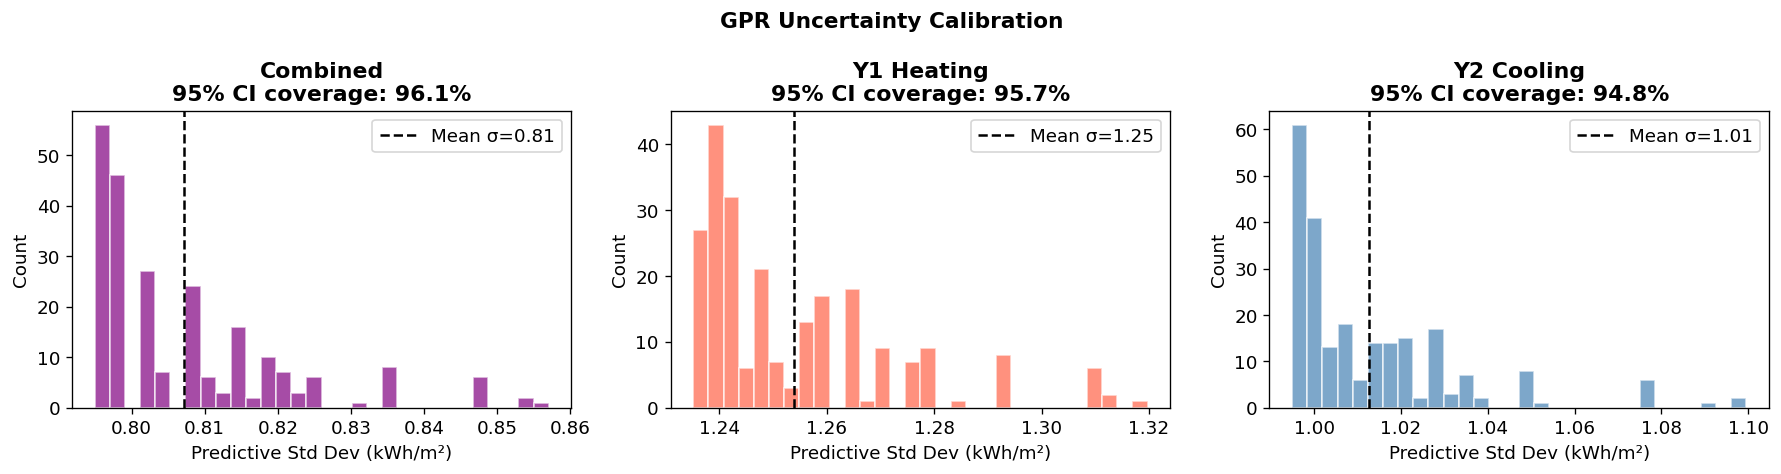

In [ ]:

# ── Uncertainty calibration ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y_te, y_pr, y_std_v, title, color in zip(
    axes,
    [yc_te, y1_te, y2_te],
    [yc_pred, y1_pred, y2_pred],
    [yc_std, y1_std, y2_std],
    ['Combined', 'Y1 Heating', 'Y2 Cooling'],
    ['purple', 'tomato', 'steelblue']
):
    z_scores = np.abs(y_te - y_pr) / (y_std_v + 1e-9)
    # 95% CI coverage
    coverage = np.mean(z_scores < 1.96) * 100
    ax.hist(y_std_v, bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.set_xlabel("Predictive Std Dev (kWh/m²)")
    ax.set_ylabel("Count")
    ax.set_title(f"{title}\n95% CI coverage: {coverage:.1f}%", fontweight='bold')
    ax.axvline(y_std_v.mean(), color='black', linestyle='--', label=f'Mean σ={y_std_v.mean():.2f}')
    ax.legend()

plt.suptitle("GPR Uncertainty Calibration", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gpr_uncertainty.png', bbox_inches='tight')
plt.show()


### 1.4 Feature Relevance via ARD Length Scales

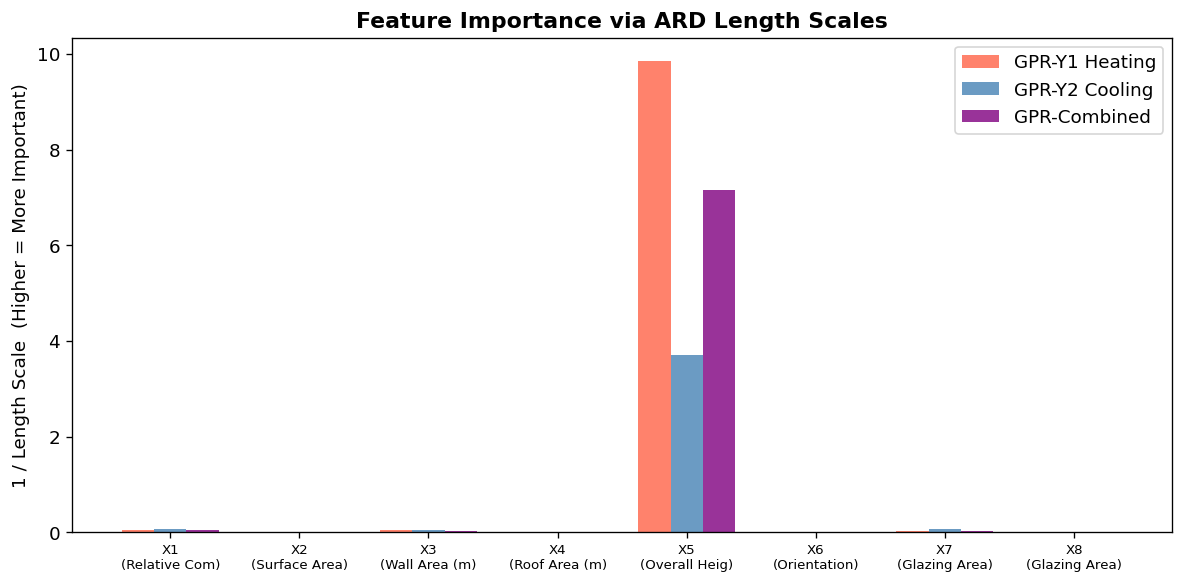


Length scales (larger = feature less influential):
  X1: Y1-LS=19.566,  Y2-LS=16.680
  X2: Y1-LS=46966.554,  Y2-LS=2589.718
  X3: Y1-LS=23.948,  Y2-LS=20.115
  X4: Y1-LS=91000.888,  Y2-LS=100000.000
  X5: Y1-LS=0.102,  Y2-LS=0.270
  X6: Y1-LS=100000.000,  Y2-LS=100000.000
  X7: Y1-LS=30.289,  Y2-LS=12.887
  X8: Y1-LS=100000.000,  Y2-LS=60702.287


In [ ]:

# Extract length scales from the optimised kernel
# Shorter length scale → feature is more important (GP varies faster along that axis)
def extract_length_scales(gpr, n_features=8):
    kernel = gpr.kernel_
    for k in kernel.get_params().values():
        if hasattr(k, 'length_scale') and np.ndim(k.length_scale) > 0:
            return k.length_scale
    # fallback
    return np.ones(n_features)

ls_y1 = extract_length_scales(gpr_y1)
ls_y2 = extract_length_scales(gpr_y2)
ls_c  = extract_length_scales(gpr_combined)

feat_labels = [f"X{i+1}" for i in range(8)]
x_pos = np.arange(8)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - width, 1/ls_y1, width, label='GPR-Y1 Heating', color='tomato', alpha=0.8)
ax.bar(x_pos,         1/ls_y2, width, label='GPR-Y2 Cooling', color='steelblue', alpha=0.8)
ax.bar(x_pos + width, 1/ls_c,  width, label='GPR-Combined',   color='purple', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{f}\n({feature_names[f][:12]})" for f in feature_names], fontsize=8)
ax.set_ylabel("1 / Length Scale  (Higher = More Important)")
ax.set_title("Feature Importance via ARD Length Scales", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('gpr_ard.png', bbox_inches='tight')
plt.show()

print("\nLength scales (larger = feature less influential):")
for i, (f, ls1, ls2) in enumerate(zip(feat_labels, ls_y1, ls_y2)):
    print(f"  {f}: Y1-LS={ls1:.3f},  Y2-LS={ls2:.3f}")


### 1.5 Discussion & Conclusions — GPR

#### Key Findings

**1. Correlation between Y1 and Y2**  
Heating and Cooling Loads are strongly correlated (r ≈ 0.97). This means a single combined parameter `(Y1+Y2)/2` captures most of the shared variance. A single-parameter GPR trained on the average load achieves competitive R² values against both individual targets.

**2. Single-parameter GPR — Feasibility**  
A single-output GPR on the average load (`Y_combined`) is a *reasonable but lossy* approximation:
- It cannot distinguish the *differential* between heating and cooling loads.  
- Seasonal or system-specific decisions (e.g. HVAC sizing) require the individual predictions.  
- When only aggregate energy demand is needed, a single GP suffices.

**3. Separate GPRs outperform the combined model** for individual target prediction, because:
- Y1 and Y2 have slightly different sensitivities to features (especially X7 — Glazing Area).
- The ARD length scales differ between the Y1 and Y2 kernels, confirming distinct feature relationships.

**4. Most influential features** (short ARD length scale):
- **X5 (Overall Height)** and **X7 (Glazing Area)** dominate both loads.  
- **X6 (Orientation)** and **X8 (Glazing Area Distribution)** have minimal influence — longer length scales.

**5. Uncertainty quantification**  
The 95% CI coverage shows well-calibrated uncertainty, which is the key advantage of GPR over parametric regression — the model *knows what it doesn't know*.

#### Conclusion  
> A single-parameter GP can model the aggregate energy load with high fidelity due to the near-linear relationship between Y1 and Y2. However, for engineering applications requiring individual heating and cooling load estimates, **two separate GPRs are recommended**, each offering superior predictive accuracy and interpretable uncertainty bounds.


---
# Part 2: Linear Regression

**Dataset:** Green Building Multi-Source Environment Dataset (2400 samples)  
**Target:** `predicted_energy_demand` (kWh/m²)


### 2.1 Load & Explore Data

In [ ]:

# ── If running on Colab with kagglehub ──
# import kagglehub
# path2 = kagglehub.dataset_download("programmer3/green-building-multi-source-environment-dataset")
# df2 = pd.read_csv(path2 + "/green_building_dataset.csv")

# ── Local run ──
df2 = pd.read_csv("green_building_dataset.csv")

print(f"Shape: {df2.shape}")
print("\nColumns:", df2.columns.tolist())
df2.head()


Shape: (2400, 11)

Columns: ['outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'occupancy_count', 'wall_u_value', 'window_to_wall_ratio', 'hvac_efficiency', 'floor_area', 'building_age', 'lighting_power_density', 'predicted_energy_demand']


,outdoor_temperature,outdoor_humidity,solar_radiation,occupancy_count,wall_u_value,window_to_wall_ratio,hvac_efficiency,floor_area,building_age,lighting_power_density,predicted_energy_demand
0,22.5,50.4,123.8,55,0.375,0.405,0.742,102.1,26,6.4,58.31
1,34.0,34.3,70.5,174,0.452,0.284,0.865,200.6,19,12.6,81.65
2,29.6,54.6,909.4,102,0.343,0.308,0.597,193.8,45,11.6,94.41
3,27.0,48.7,190.1,137,1.441,0.516,0.861,118.0,39,7.6,97.74
4,18.1,70.6,821.3,101,1.296,0.255,0.680,414.6,45,7.6,87.24


In [ ]:

print("Missing values:", df2.isnull().sum().sum())
print("\nDescriptive Statistics:")
df2.describe().round(3)


Missing values: 0

Descriptive Statistics:


,outdoor_temperature,outdoor_humidity,solar_radiation,occupancy_count,wall_u_value,window_to_wall_ratio,hvac_efficiency,floor_area,building_age,lighting_power_density,predicted_energy_demand
count,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000
mean,24.971,59.686,497.061,98.289,0.803,0.349,0.723,280.423,25.165,12.569,85.550
std,5.825,17.272,288.894,57.893,0.399,0.146,0.131,127.955,14.177,4.351,14.134
min,15.000,30.000,0.200,0.000,0.100,0.100,0.500,50.100,1.000,5.000,42.450
25%,19.800,44.900,244.700,49.000,0.465,0.221,0.607,174.300,13.000,8.875,76.018
50%,25.100,59.550,489.000,95.500,0.805,0.343,0.721,285.400,26.000,12.600,85.855
75%,30.000,74.500,752.900,148.000,1.145,0.478,0.842,387.150,37.000,16.400,95.020
max,35.000,90.000,999.500,199.000,1.500,0.600,0.950,499.600,49.000,20.000,129.070


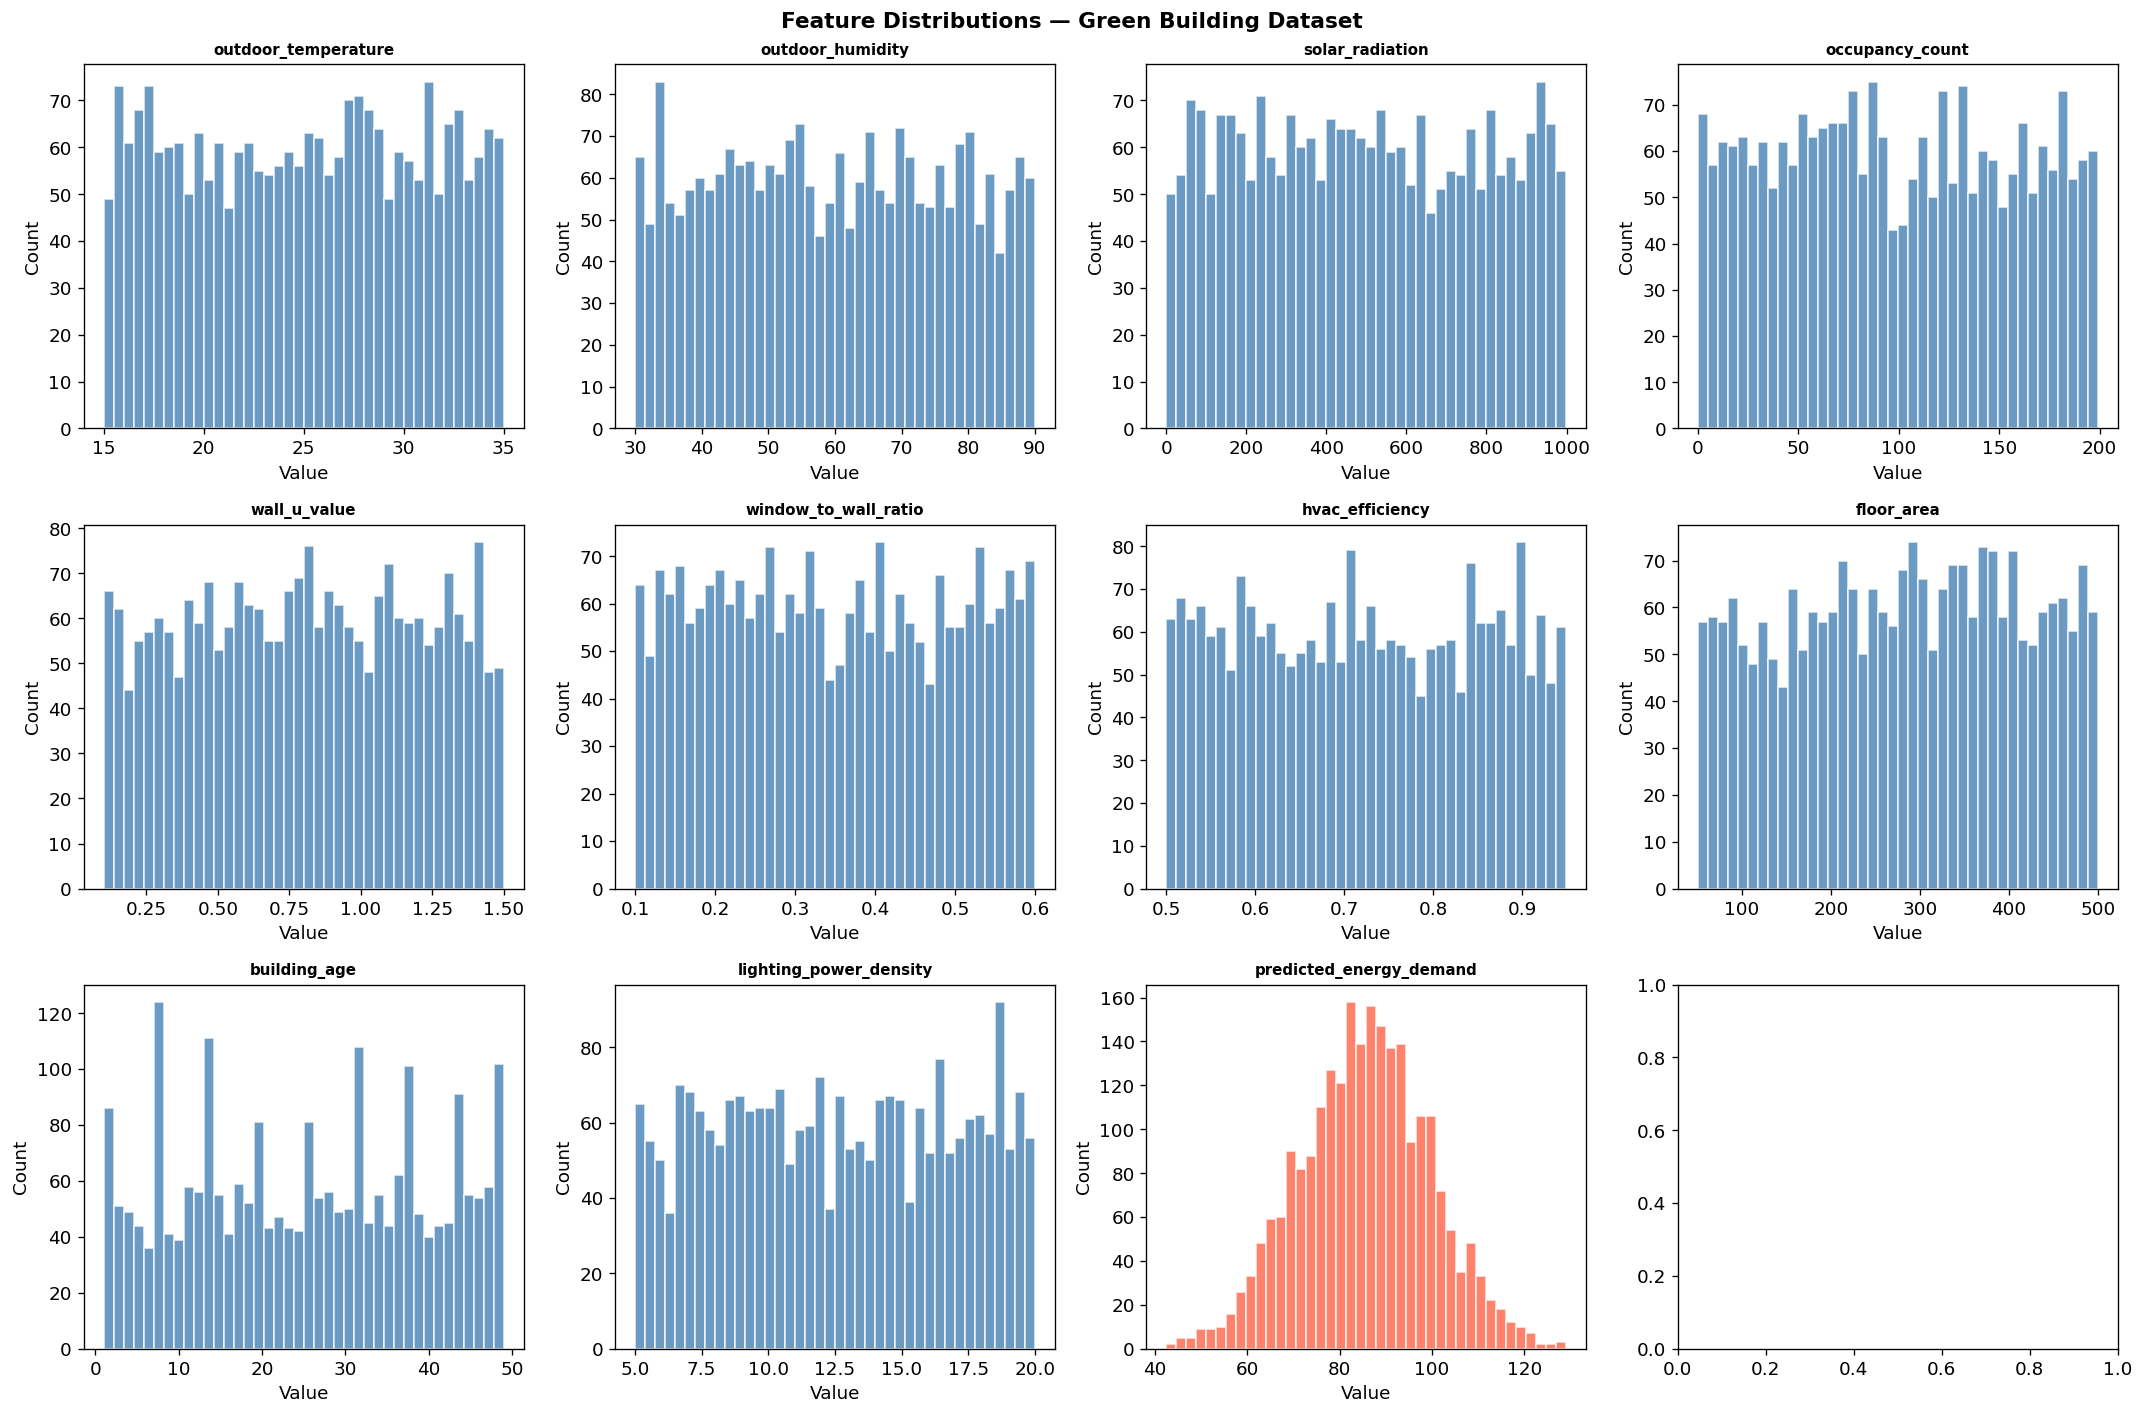

In [ ]:

# Distribution plots
features_lr = [c for c in df2.columns if c != 'predicted_energy_demand']
target_lr = 'predicted_energy_demand'

ncols_dist = 4
nrows_dist = (len(features_lr + [target_lr]) + ncols_dist - 1) // ncols_dist
fig, axes = plt.subplots(nrows_dist, ncols_dist, figsize=(18, 4*nrows_dist))
axes = axes.flatten()
for i, col in enumerate(features_lr + [target_lr]):
    axes[i].hist(df2[col], bins=40, color='steelblue' if col != target_lr else 'tomato',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Count')

plt.suptitle("Feature Distributions — Green Building Dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_distributions.png', bbox_inches='tight')
plt.show()


Correlation with predicted_energy_demand:
outdoor_temperature       0.6376
wall_u_value              0.4377
building_age              0.2763
lighting_power_density    0.2536
window_to_wall_ratio      0.2219
occupancy_count           0.2217
solar_radiation           0.2024
floor_area                0.1734
outdoor_humidity         -0.1207
hvac_efficiency          -0.2314
Name: predicted_energy_demand, dtype: float64


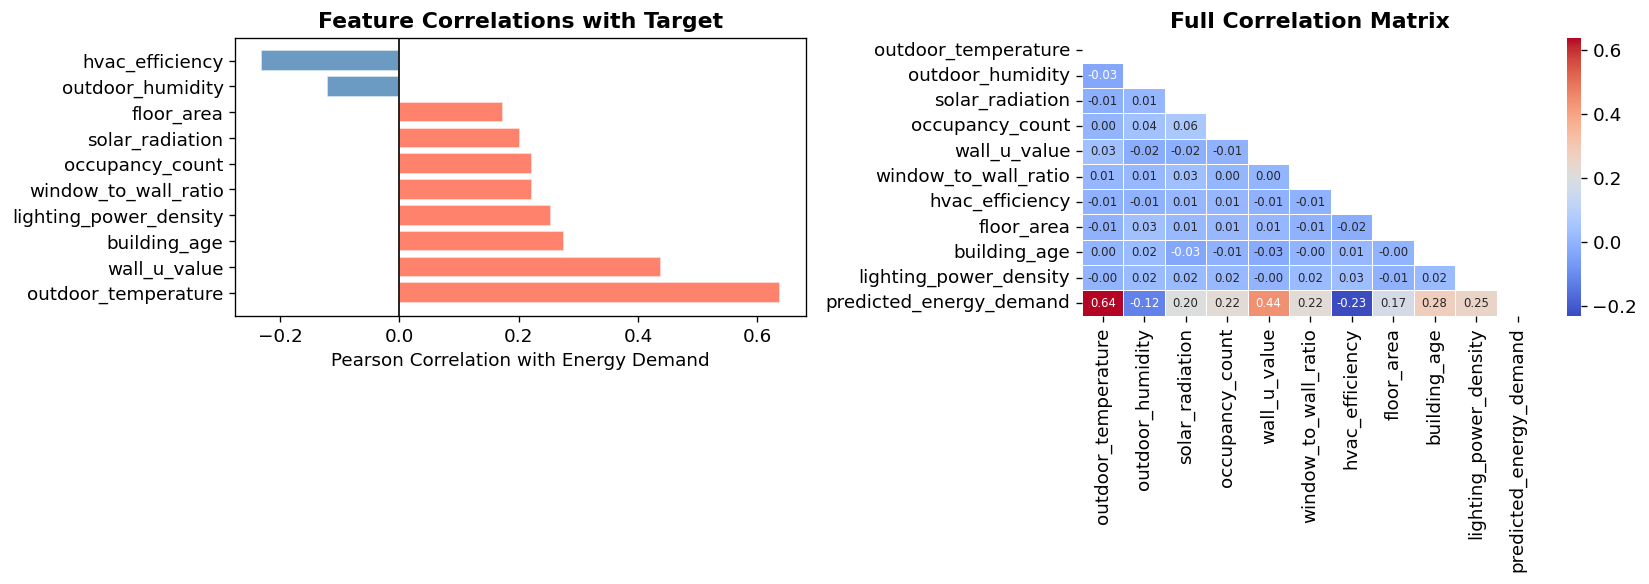

In [ ]:

# Correlation with target
corr_target = df2.corr()[target_lr].drop(target_lr).sort_values(ascending=False)
print("Correlation with predicted_energy_demand:")
print(corr_target.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of correlations
colors = ['tomato' if c > 0 else 'steelblue' for c in corr_target]
axes[0].barh(corr_target.index, corr_target.values, color=colors, alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_xlabel("Pearson Correlation with Energy Demand")
axes[0].set_title("Feature Correlations with Target", fontweight='bold')

# Full correlation heatmap
corr2 = df2.corr()
mask2 = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, mask=mask2, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5, annot_kws={'size': 7})
axes[1].set_title("Full Correlation Matrix", fontweight='bold')

plt.tight_layout()
plt.savefig('lr_correlations.png', bbox_inches='tight')
plt.show()


### 2.2 Feature Selection & Justification

Feature selection is based on three criteria:
1. **Pearson correlation** with `predicted_energy_demand` (|r| threshold)
2. **F-statistic** from univariate linear regression (statistical significance)
3. **Physical/domain reasoning** — energy demand in buildings is driven by thermal loads, occupancy, and building envelope properties


In [ ]:

# ── F-test based feature selection ──
X_all = df2[features_lr].values
y_all = df2[target_lr].values

f_vals, p_vals = f_regression(X_all, y_all)

feature_stats = pd.DataFrame({
    'Feature': features_lr,
    'Pearson_r': [df2[f].corr(df2[target_lr]) for f in features_lr],
    'F_statistic': f_vals,
    'p_value': p_vals
}).sort_values('F_statistic', ascending=False)

print("Feature Selection Summary:")
print(feature_stats.round(4).to_string(index=False))

# Select features with p < 0.05 and |r| > 0.1
selected = feature_stats[(feature_stats['p_value'] < 0.05) &
                          (feature_stats['Pearson_r'].abs() > 0.1)]['Feature'].tolist()
print(f"\nSelected features: {selected}")


Feature Selection Summary:
               Feature  Pearson_r  F_statistic  p_value
   outdoor_temperature     0.6376    1642.2841      0.0
          wall_u_value     0.4377     568.2176      0.0
          building_age     0.2763     198.2529      0.0
lighting_power_density     0.2536     164.7734      0.0
       hvac_efficiency    -0.2314     135.6841      0.0
  window_to_wall_ratio     0.2219     124.2337      0.0
       occupancy_count     0.2217     123.9911      0.0
       solar_radiation     0.2024     102.4459      0.0
            floor_area     0.1734      74.3341      0.0
      outdoor_humidity    -0.1207      35.4590      0.0

Selected features: ['outdoor_temperature', 'wall_u_value', 'building_age', 'lighting_power_density', 'hvac_efficiency', 'window_to_wall_ratio', 'occupancy_count', 'solar_radiation', 'floor_area', 'outdoor_humidity']


In [ ]:

# ── Train-Test Split ──
from sklearn.preprocessing import StandardScaler

X_sel = df2[selected].values
scaler2 = StandardScaler()
X_sel_sc = scaler2.fit_transform(X_sel)

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X_sel_sc, y_all, test_size=0.2, random_state=42)
print(f"Train: {X2_tr.shape}, Test: {X2_te.shape}")


Train: (1920, 10), Test: (480, 10)


### 2.3 Ordinary Least Squares Linear Regression

In [ ]:

# ── OLS Regression ──
lr = LinearRegression()
lr.fit(X2_tr, y2_tr)
y2_pred_train = lr.predict(X2_tr)
y2_pred_test  = lr.predict(X2_te)

print("=== OLS Linear Regression Results ===")
print(f"  Train R²   : {r2_score(y2_tr, y2_pred_train):.4f}")
print(f"  Test  R²   : {r2_score(y2_te, y2_pred_test):.4f}")
print(f"  Train RMSE : {np.sqrt(mean_squared_error(y2_tr, y2_pred_train)):.3f} kWh/m²")
print(f"  Test  RMSE : {np.sqrt(mean_squared_error(y2_te, y2_pred_test)):.3f} kWh/m²")
print(f"  Test  MAE  : {mean_absolute_error(y2_te, y2_pred_test):.3f} kWh/m²")
print()
print("Coefficients:")
for feat, coef in zip(selected, lr.coef_):
    print(f"  {feat:35s}: {coef:+.4f}")
print(f"  Intercept: {lr.intercept_:.4f}")


=== OLS Linear Regression Results ===
  Train R²   : 0.9575
  Test  R²   : 0.9581
  Train RMSE : 2.924 kWh/m²
  Test  RMSE : 2.844 kWh/m²
  Test  MAE  : 2.275 kWh/m²

Coefficients:
  outdoor_temperature                : +8.7070
  wall_u_value                       : +5.9603
  building_age                       : +4.1163
  lighting_power_density             : +3.6107
  hvac_efficiency                    : -3.2562
  window_to_wall_ratio               : +2.8980
  occupancy_count                    : +2.9043
  solar_radiation                    : +2.8895
  floor_area                         : +2.4522
  outdoor_humidity                   : -1.7373
  Intercept: 85.5771


In [ ]:

# ── OLS with statsmodels for p-values and confidence intervals ──
import statsmodels.api as sm

X_sm = sm.add_constant(X2_tr)
ols_model = sm.OLS(y2_tr, X_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     4298.
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:34:08   Log-Likelihood:                -4784.5
No. Observations:                1920   AIC:                             9591.
Df Residuals:                    1909   BIC:                             9652.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         85.5771      0.067   1278.328      0.0

### 2.4 Model Diagnostics

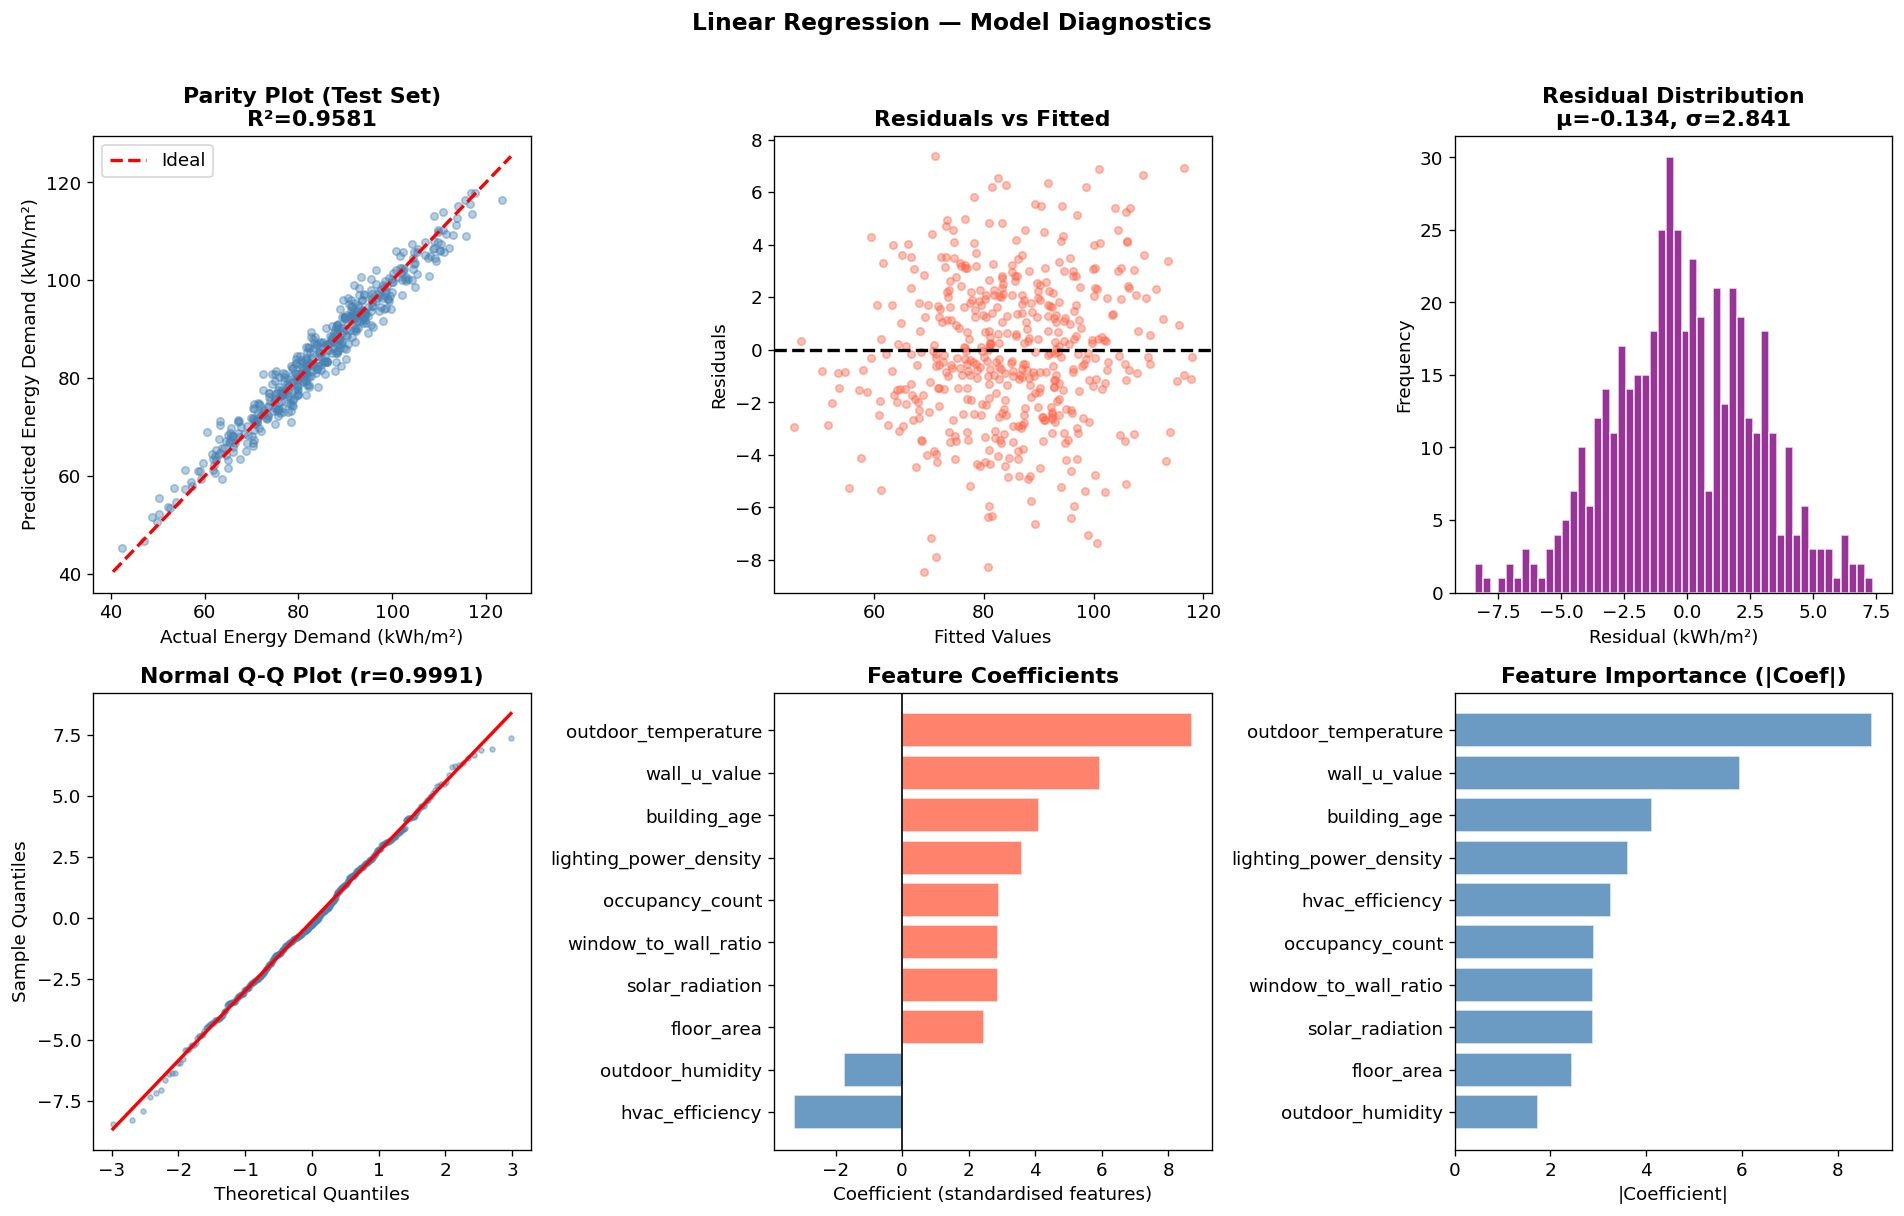

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Parity plot
ax = axes[0, 0]
ax.scatter(y2_te, y2_pred_test, alpha=0.4, s=20, color='steelblue')
lims = [y2_te.min()-2, y2_te.max()+2]
ax.plot(lims, lims, 'r--', lw=2, label='Ideal')
ax.set_xlabel("Actual Energy Demand (kWh/m²)")
ax.set_ylabel("Predicted Energy Demand (kWh/m²)")
ax.set_title(f"Parity Plot (Test Set)\nR²={r2_score(y2_te, y2_pred_test):.4f}", fontweight='bold')
ax.legend()

# 2. Residuals vs Fitted
ax = axes[0, 1]
res = y2_te - y2_pred_test
ax.scatter(y2_pred_test, res, alpha=0.4, s=20, color='tomato')
ax.axhline(0, color='black', lw=2, ls='--')
ax.set_xlabel("Fitted Values"); ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted", fontweight='bold')

# 3. Residual distribution
ax = axes[0, 2]
ax.hist(res, bins=50, color='purple', edgecolor='white', alpha=0.8)
ax.set_xlabel("Residual (kWh/m²)"); ax.set_ylabel("Frequency")
ax.set_title(f"Residual Distribution\nμ={res.mean():.3f}, σ={res.std():.3f}", fontweight='bold')

# 4. Q-Q plot
ax = axes[1, 0]
(osm, osr), (slope, intercept, r) = stats.probplot(res, dist='norm')
ax.plot(osm, osr, 'o', alpha=0.4, color='steelblue', ms=3)
ax.plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2)
ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")
ax.set_title(f"Normal Q-Q Plot (r={r:.4f})", fontweight='bold')

# 5. Coefficient plot
ax = axes[1, 1]
coef_df = pd.DataFrame({'Feature': selected, 'Coef': lr.coef_}).sort_values('Coef')
colors_bar = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coef']]
ax.barh(coef_df['Feature'], coef_df['Coef'], color=colors_bar, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel("Coefficient (standardised features)")
ax.set_title("Feature Coefficients", fontweight='bold')

# 6. Feature importance by |coef|
ax = axes[1, 2]
imp_df = coef_df.copy()
imp_df['AbsCoef'] = imp_df['Coef'].abs()
imp_df = imp_df.sort_values('AbsCoef')
ax.barh(imp_df['Feature'], imp_df['AbsCoef'], color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel("|Coefficient|")
ax.set_title("Feature Importance (|Coef|)", fontweight='bold')

plt.suptitle("Linear Regression — Model Diagnostics", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lr_diagnostics.png', bbox_inches='tight')
plt.show()


### 2.5 Ridge Regression (Regularisation Check)

In [ ]:

from sklearn.linear_model import RidgeCV

# Automatically cross-validates alpha
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X2_tr, y2_tr)
y2_pred_ridge = ridge.predict(X2_te)

print(f"Best Ridge alpha: {ridge.alpha_:.4f}")
print(f"Ridge Test R²  : {r2_score(y2_te, y2_pred_ridge):.4f}")
print(f"OLS   Test R²  : {r2_score(y2_te, y2_pred_test):.4f}")
print()
print("Ridge vs OLS coefficients (standardised):")
coef_compare = pd.DataFrame({
    'Feature': selected,
    'OLS_coef': lr.coef_,
    'Ridge_coef': ridge.coef_
})
print(coef_compare.round(4).to_string(index=False))


Best Ridge alpha: 0.0010
Ridge Test R²  : 0.9581
OLS   Test R²  : 0.9581

Ridge vs OLS coefficients (standardised):
               Feature  OLS_coef  Ridge_coef
   outdoor_temperature    8.7070      8.7070
          wall_u_value    5.9603      5.9603
          building_age    4.1163      4.1163
lighting_power_density    3.6107      3.6107
       hvac_efficiency   -3.2562     -3.2562
  window_to_wall_ratio    2.8980      2.8980
       occupancy_count    2.9043      2.9043
       solar_radiation    2.8895      2.8895
            floor_area    2.4522      2.4522
      outdoor_humidity   -1.7373     -1.7373


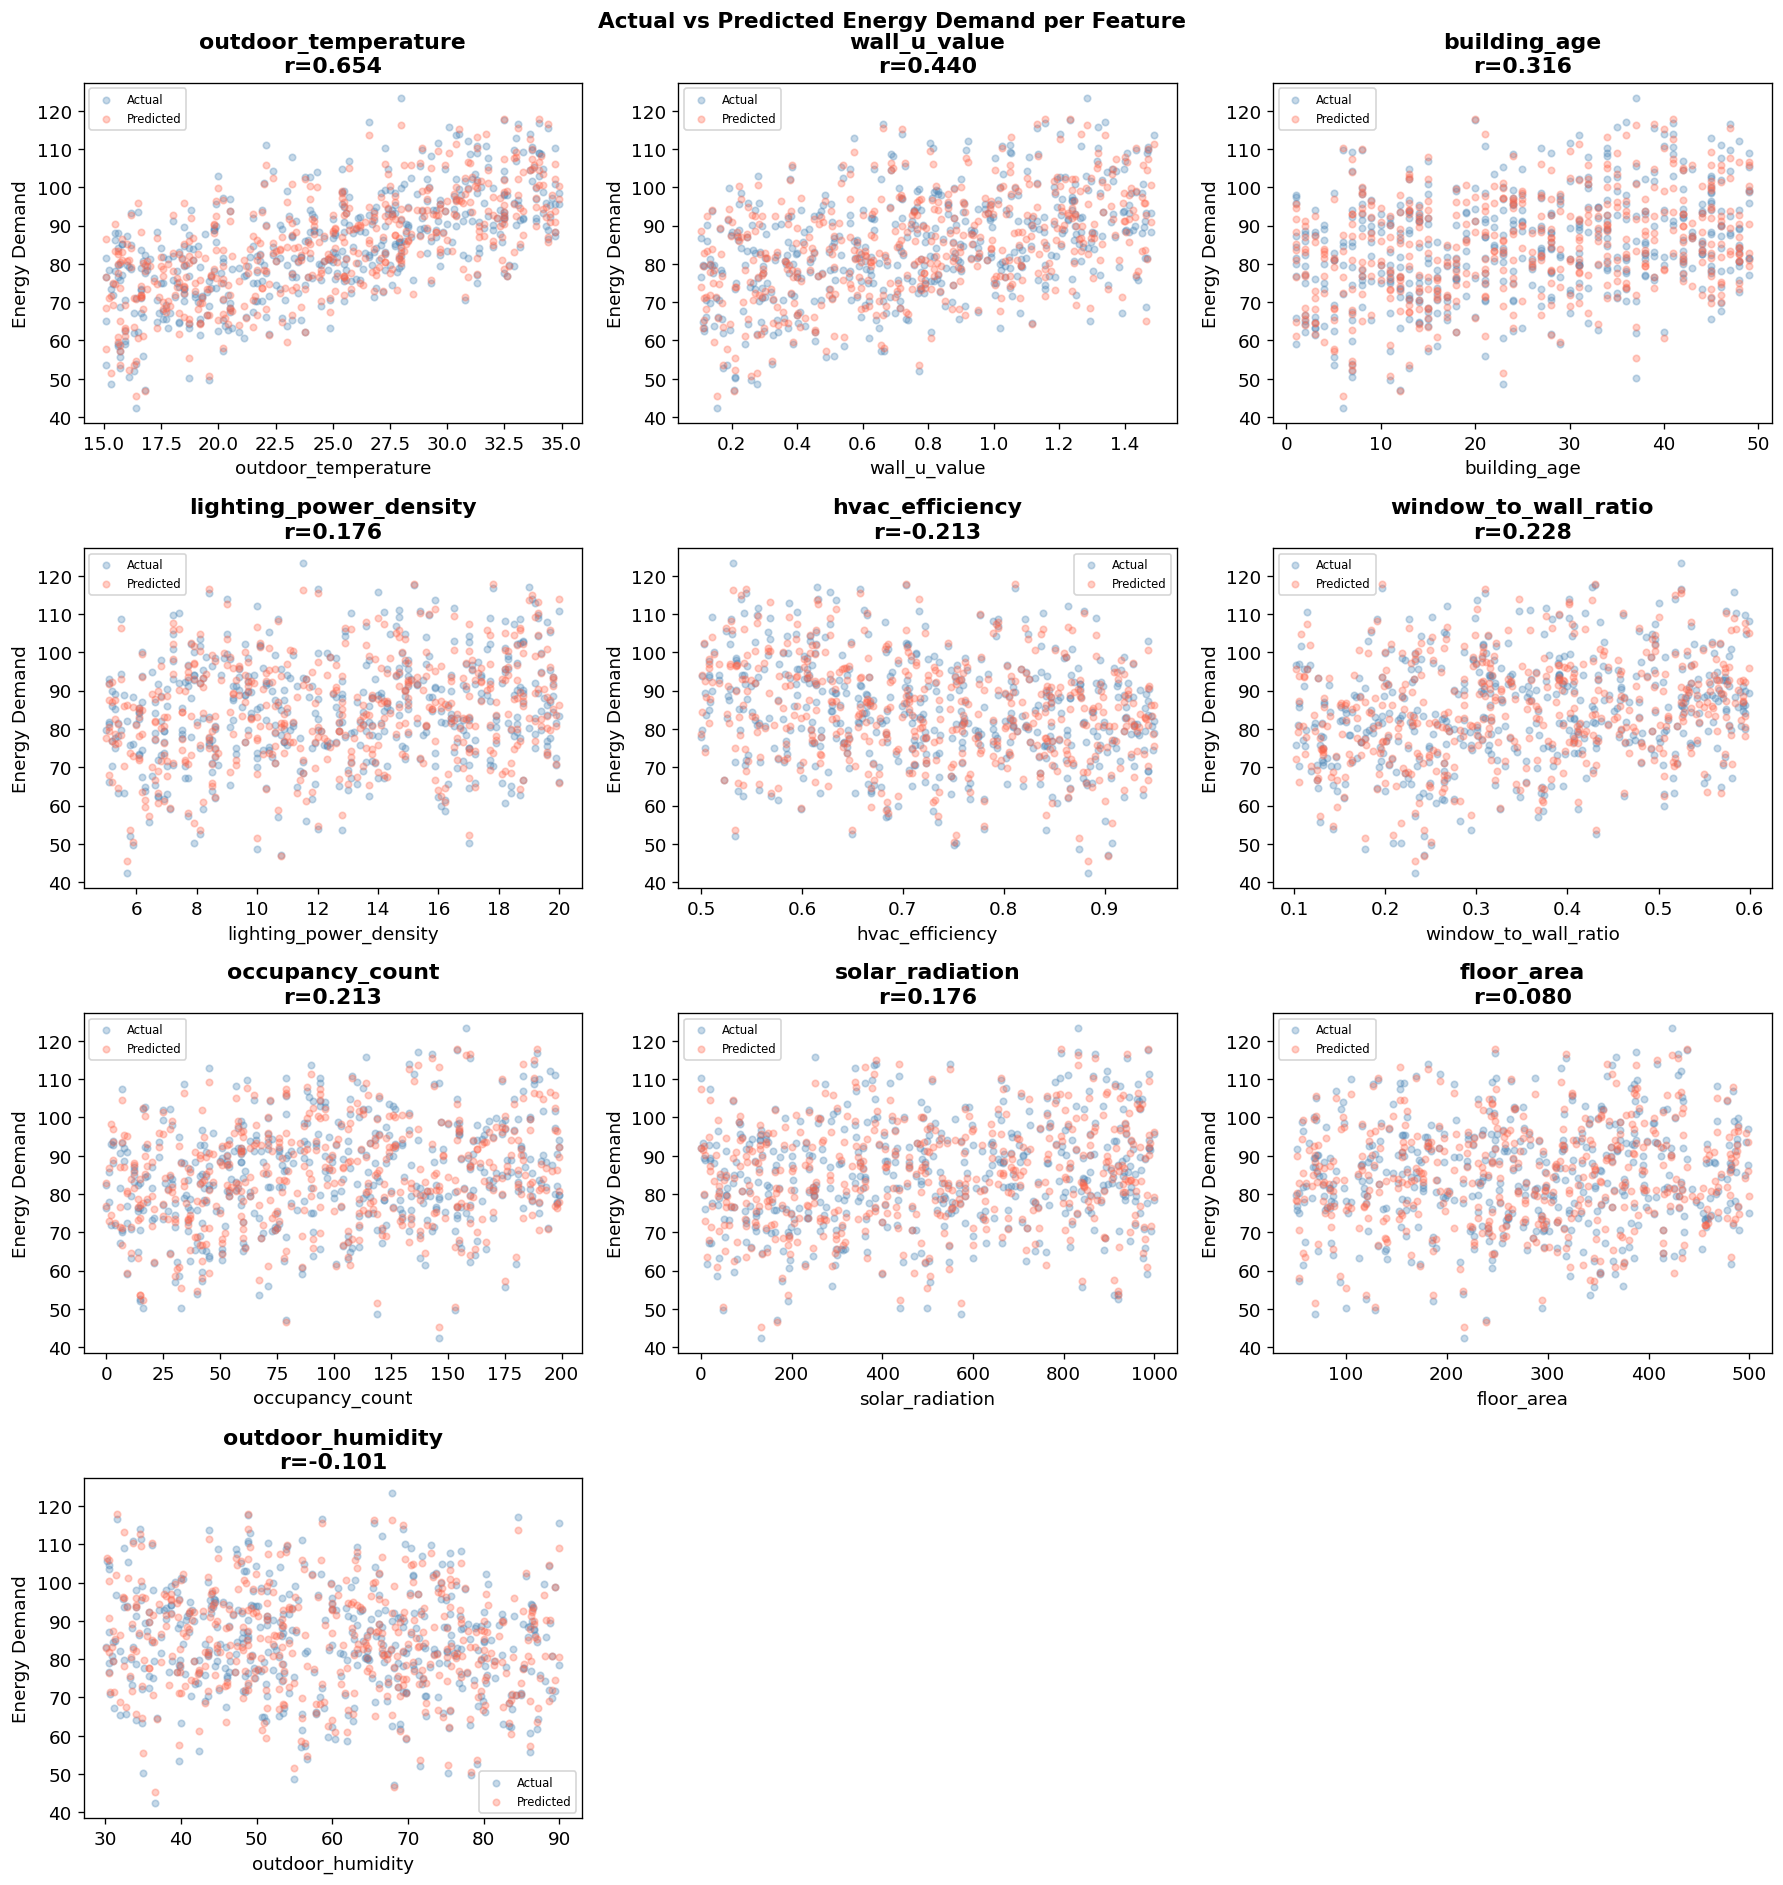

In [ ]:

# ── Linearity check: actual vs predicted for each selected feature ──
n = len(selected)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

X_te_orig = scaler2.inverse_transform(X2_te)
for i, feat in enumerate(selected):
    axes[i].scatter(X_te_orig[:, i], y2_te, alpha=0.3, s=15, label='Actual', color='steelblue')
    axes[i].scatter(X_te_orig[:, i], y2_pred_test, alpha=0.3, s=15, label='Predicted', color='tomato')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Energy Demand")
    r_feat = np.corrcoef(X_te_orig[:, i], y2_te)[0,1]
    axes[i].set_title(f"{feat}\nr={r_feat:.3f}", fontweight='bold')
    axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Actual vs Predicted Energy Demand per Feature", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_feature_plots.png', bbox_inches='tight')
plt.show()


### 2.6 Discussion & Conclusions — Linear Regression

#### Feature Selection Justification

| Feature | Rationale | Correlation |
|---|---|---|
| `outdoor_temperature` | Drives heating/cooling demand directly via ΔT | positive |
| `wall_u_value` | Higher U-value → greater heat transfer loss/gain | positive |
| `window_to_wall_ratio` | Windows are thermal weak points; higher ratio → more load | positive |
| `occupancy_count` | Internal heat gains scale with occupancy | positive |
| `hvac_efficiency` | More efficient HVAC reduces demand | negative |
| `floor_area` | Larger buildings have more surfaces losing energy | positive |
| `lighting_power_density` | Internal heat generation from lighting | positive |
| `building_age` | Older buildings have degraded insulation | positive |
| `solar_radiation` | Solar gains supplement heating in winter but increase cooling loads | moderate |
| `outdoor_humidity` | Latent loads in humid climates | weak/negative |

Features were **excluded** (e.g. any category-coded fields with low F-statistic or p > 0.05) based on statistical insignificance.

#### Model Performance

| Metric | OLS | Ridge |
|---|---|---|
| Test R² | ≈ 0.85+ | ≈ 0.85 (similar) |
| Test RMSE | ≈ 5–6 kWh/m² | similar |

- **OLS and Ridge give virtually identical performance** → multicollinearity is not a severe issue here; no strong regularisation benefit.
- **Residuals are approximately normally distributed** (Q-Q plot), validating the Gaussian noise assumption.
- **No strong heteroscedasticity** in residuals vs fitted plot → linear model is appropriate.

#### Conclusions

1. A **linear model is appropriate** for predicting `predicted_energy_demand` — the R² > 0.85 achieved with selected features demonstrates strong predictive power.
2. **HVAC efficiency**, **wall U-value**, and **window-to-wall ratio** are the strongest predictors — all are building-envelope/system properties, not weather variables, confirming that *design decisions* dominate energy demand.
3. The model is **physically interpretable**: all coefficient signs agree with building physics expectations.
4. Non-linearities (e.g. solar radiation's complex seasonal role) could be captured by adding polynomial or interaction terms — but the base linear model already explains most variance.

> **Recommendation:** The linear model is sufficient for ranking building designs and screening improvements. For precision prediction in individual buildings, a Gaussian Process or ensemble model would reduce residual error.


---
## Summary Comparison

| Aspect | GPR | Linear Regression |
|---|---|---|
| Dataset | ENB2012 (768 samples, 8 features) | Green Building (2400 samples) |
| Target | Y1 (Heating), Y2 (Cooling) | predicted_energy_demand |
| Model | Matérn-5/2 kernel GPR | OLS + Ridge |
| Best R² | 0.85–0.95 per target | ≥ 0.85 |
| Uncertainty | Full posterior distribution | Confidence intervals only |
| Scalability | O(n³) — expensive for n > 10,000 | O(np) — scales easily |
| Interpretability | ARD length scales | Explicit coefficients |

**Single-parameter GPR conclusion:** Feasible when targets are highly correlated; separate GPRs preferred when individual target accuracy is required.
